# Normal distribution

---

#### Summary videos

- [Normal distribution](https://youtu.be/S_p5D-YXLS4?si=y9sGpL45j7UoXoNB) (20 minutes)

#### Walkthrough videos

- [The normal distribution](https://drive.google.com/file/d/1BbwgfwwK9Vs69538ItqDCX8ESW_K9kx7/view?usp=sharing) (11 minutes)
- [Standardizing with Z-scores](https://drive.google.com/file/d/1F767xB-92n7jLHd5TYkD-lWSLFhxCiER/view?usp=sharing) (10 minutes)
- [Areas and probabilities](https://drive.google.com/file/d/1CVNGXMq_N7nB-ZW_bMkzt8SU1iPqVT_4/view?usp=sharing) (22 minutes)

---

Let's consider the following data on SAT scores.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from plotnine import *

satgpa = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/satgpa.csv')
satgpa.head()

In [ ]:
satgpa.shape

This data set contains information on 1000 students SAT scores along with their highschool GPA. We'll focus on the overall SAT scores, so we'll carve out a dataframe from `sat_sum`.

In [ ]:
SAT = satgpa['sat_sum']
SAT.head()

Now, it looks like the SAT scores recorded are actually divided by 10 from the original score. We'll multiply our data by 10 to accommodate.

In [ ]:
SAT = 10 * SAT
SAT.head()

### Exercise
Create a numerical summary of `SAT` and use a histogram to describe the distribution of this data.

In [ ]:
SAT.describe()

In [ ]:
(
    ggplot(pd.DataFrame(SAT)) +
    aes(x = 'sat_sum') +
    geom_histogram(binwidth = 50)
)

## The normal distribution model

As we see with the `SAT` (along with several other data sets previously), many variables follow a distribution that is
* Symmetric
* Unimodal
* Bell-shaped.

This is called a **normal curve** or **normal distribution**.

### Explore!
* Use the following link to explore the normal distribution.
  * https://www.geogebra.org/classic#probability
* Why does it makes sense that the shape of a normal distribution is determined by the two parameters $\mu$ and $\sigma$?
* Alter the parameters $\mu$ and $\sigma$ to visualize the normal model for our `SAT` data.
* How much of the data is within 1 standard deviation of the mean?
* How much of the data is within 2 standard deviations of the mean?
* How much of the data is within 3 standard deviations of the mean?

### The standard normal distribution
* A **normal distribution** with mean $\mu$ and standard deviation $\sigma$ is represented as $N(\mu, \sigma)$.
* The **standard normal distribution** has $\mu = 0$ and $\sigma = 1$, i.e., it is $N(\mu = 0, \sigma = 1)$.
  * The equation describing the standard normal curve can be written as a function: $$f(x) = \dfrac{1}{\sigma \sqrt{2\pi}} \cdot e^{-\dfrac{1}{2}\left( \dfrac{x - \mu}{\sigma} \right)^2}.$$

### 68-95-99.7 rule
Our observations from the last three questions above are captured by something called the **68-95-99.7 rule**, visualized on page 141 of the textbook as follows. This rule is useful for thinking about distributions that we know or expect to be nearly normal, as well as for determining whether or not we expect a distribution to be nearly normal.

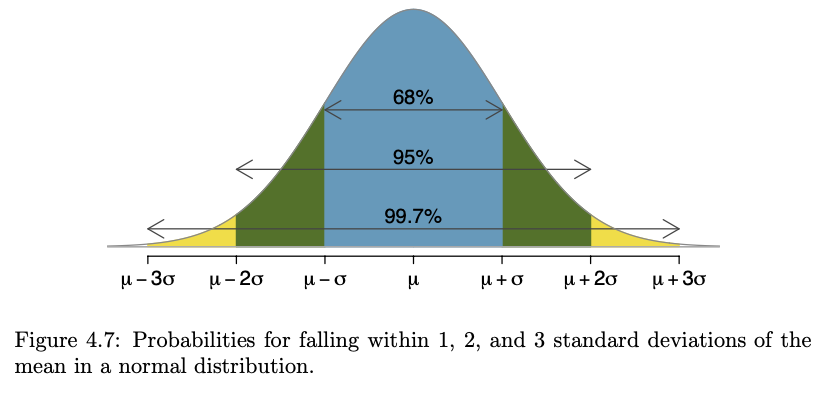

## Standardizing with Z-scores

Normal distributions are fairly complicated. So, a common practice for investigating them is to *standardize* your data in reference to the standard normal distribution. This way, we only need to think hard about the standard normal distribution—then, we can think of any other normal distribution in terms of what we already know!

### Example
Our `SAT` data follows a nearly normal distribution with parameters approximately $\mu = 1033$ and $\sigma = 143$. In symbols, it is common to write this observation as

$$ SAT \sim N(\mu = 1033, \sigma = 143).$$

* Suppose Alice scored 1176 on the SAT. How many standard deviations away from the mean is her score? `HINT: Draw a picture!`
* What about Bob, who scored 890?
* What about Alex, who scored 1247?

### Z-score
The Z-score of an observation is the number of standard deviations it falls above or below the mean.

$$Z = \dfrac{x - \mu}{\sigma} $$

### Questions
* If a Z-score is positive, does that mean the observation is bigger or smaller than the mean?
* What if a Z-score is negative?
* What is the Z-score of the mean itself?

## Areas and probabilities

As we saw in Section 3.5, probability can be respresented by the area under a continuous distribution curve.

### Question
How surprised should you be if someone scored 1319 on the SAT?

### Example (GeoGebra)
* Use https://www.geogebra.org/classic#probability to find the probability of someone scoring 1176 or lower on the SAT.
  * First, do this using the parameters $\mu = 1033$ and $\sigma = 143$.
  * Then, do it again using Z-sores instead.
  * Z-scores let us think about a distribution in terms of its *shape*. Being able to compute Z-scores will also be useful later in the course!
* What is the **percentile** of the score 1176?
* What score corresponds to the 90th percentile?
* Find the probability of someone scoring 1319 or higher on the SAT.
* Find the probability of someone scoring between 900 and 1200 on the SAT.

There are several ways to find the area under a normal distribution. Above, we used GeoGebra.

Below, we use Python, utilizing the `scipy` package to find the probability of someone scoring 1319 or higher on the SAT. Note that the `norm.cdf` function is the **cumulative distribution function** for the normal curve---it finds the area under the normal curve for all values less than or equal to the number you give it.

### Example (Python)

- Draw a picture of the area under a normal curve that would represent the probability of scoring 1319 or higher on the SAT. Then, run the code below to compute it.

In [ ]:
from scipy.stats import norm

1 - norm.cdf(1319, loc = 1033, scale = 143)

- Draw a picture of the area under a normal curve that would represent the probability of scoring 1319 or lower on the SAT. Then, use Python compute it.

In [ ]:
norm.cdf(1319, loc = 1033, scale = 143)

- Draw a picture of the area under a normal curve that would represent the probability of scoring between 900 and 1200 on the SAT. Then, use Python compute it.

In [ ]:
norm.cdf(1200, loc = 1033, scale = 143) - norm.cdf(900, loc = 1033, scale = 143)

### A word on tables
Another common way to compute these tail areas is to use **probability tables**, as shown on pages 410 and 411 of Appendix C in the textbook.

Note that probability tables are fairly common in an educational setting, but are rarely used in practice.

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.